In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys         
sys.path.insert(0, '../defs/')
import xarray as xr
from defs import NooneCurves as NC 
from defs import NooneCurves_ax as NC_ax
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [7]:
band = 'S'
bandin = 's'
bands = {'N':[5,12,10,31],'EQ':[-5,5,10,29],'S':[-15,-5,12,31]}
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
sat_ds = xr.open_dataset(datac+'hdo_day_reg_regrid.nc',engine='h5netcdf') 

chunk = 30

sat_ds = sat_ds.sel(lon=slice(bands[band][2],bands[band][3]),lat=slice(bands[band][0],bands[band][1]))

onset1 = {'N':125,'EQ':62,'S':290}
onset2 = {'N':'a','EQ':247,'S':'a'}
cessation1 = {'N':297,'EQ':142,'S':111}
cessation2 = {'N':'a','EQ':341,'S':'b'}

#print(sat_ds)

## Monthly climatology

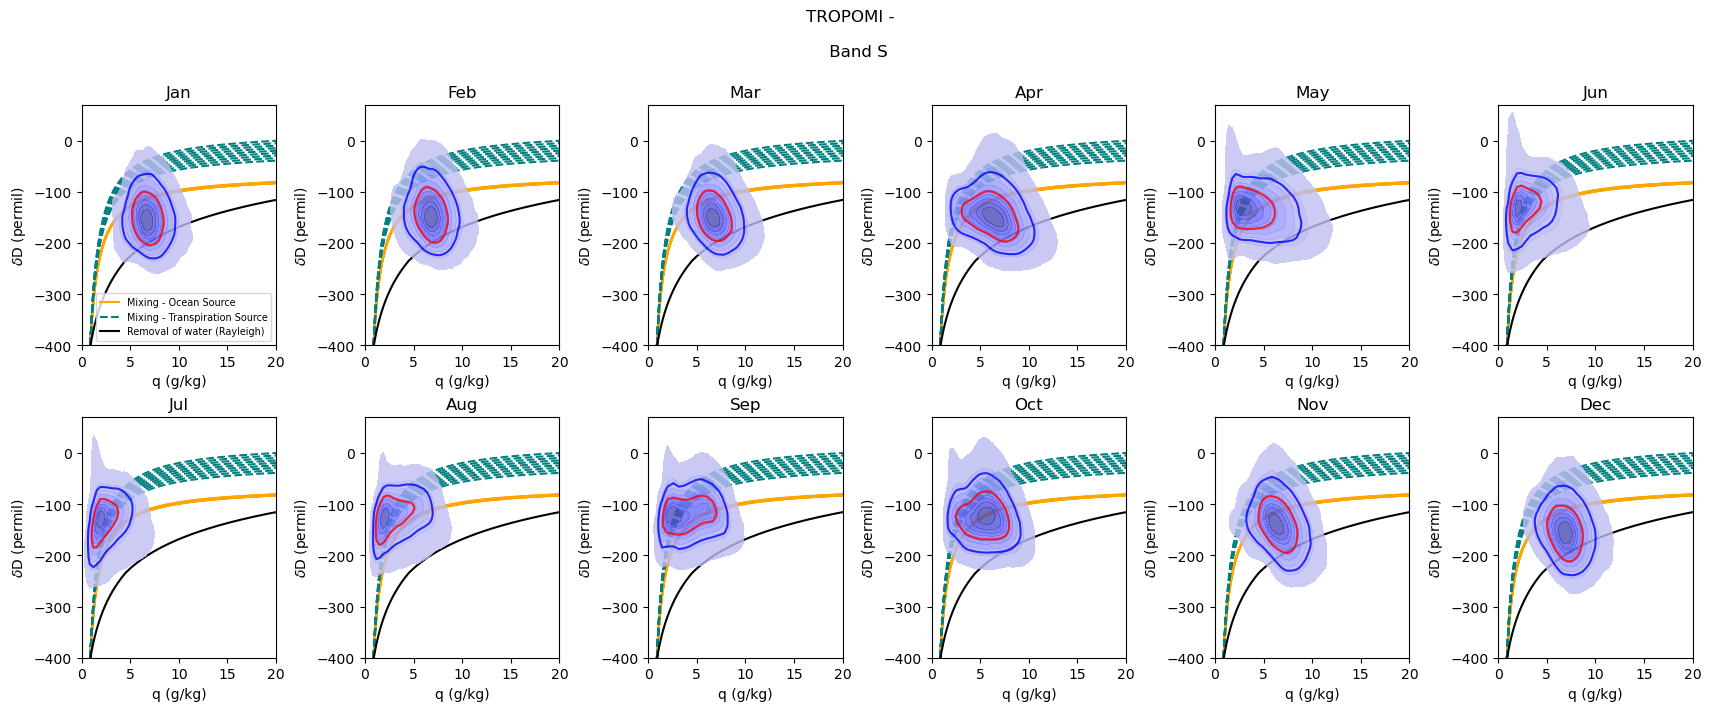

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=6
nrows=2
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(17,7))
axs=axs.flatten()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i,s in enumerate(months):
    
    df = sat_ds.sel(time=(sat_ds.time.dt.month==i+1), drop=True).to_dataframe()
    
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='red',ax=axs[i],zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,20)
    axs[i].set_ylim(-400,70)
    #axs[i].scatter(df['h2o_vmr'],df['deltaD'],s=5,alpha=0.2,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='lower right',fontsize='x-small')
plt.suptitle('TROPOMI -  \n \n Band '+band+'\n')
plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'.png',transparent=True)

plt.show()
plt.clf()
plt.close()

## Season 1

In [ ]:
ON = onset1[band]
CE = cessation1[band]
seas_avg = sat_ds.where((sat_ds['time.dayofyear']>ON)&(sat_ds['time.dayofyear']<CE),drop=True)


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,4))
    
df = seas_avg.to_dataframe()

#sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs)
sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs,zorder=0,thresh=.2)
axs.set_xlim(-5,50)
axs.set_ylim(-400,70)
axs.scatter(1000.*seas_avg['h2o_vmr'],seas_avg['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=0)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
axs.legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 1 Avg - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPOMI_noone_curves_'+band+'_S1_avg.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 1 Onset

In [ ]:
seas1 = {}

#seas1[str((chunk*3))+'-'+str((chunk*2))+' days pre-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*3)))&(sat_ds['time.dayofyear']<(ON-(chunk*2))),drop=True)
seas1[str((chunk*2))+'-'+str((chunk*1))+' days to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*2)))&(sat_ds['time.dayofyear']<(ON-(chunk*1))),drop=True)
seas1[str((chunk*1))+' days pre-onset to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*1)))&(sat_ds['time.dayofyear']<(ON)),drop=True)
seas1['Onset to '+str(chunk*1)+' days post-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON))&(sat_ds['time.dayofyear']<(ON+(chunk*1))),drop=True)

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(14,5))
axs=axs.flatten()
for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()

    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='red',ax=axs[i],zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,20)
    axs[i].set_ylim(-400,70)
    #sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    axs[i].scatter(seas1[s]['h2o_vmr'],seas1[s]['deltaD'],s=5,alpha=0.2,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 1 \n \n Band '+band+'\n')
plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S1_ON.png',transparent=True)

plt.show()
plt.clf()
plt.close()

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(5,5))
n_lines = 5
cmap = mpl.colormaps['plasma']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))

for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()

    #sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
    #        alpha=0.8,color='blue',ax=axs,zorder=1)
    #sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
    #                alpha=0.8,color='red',ax=axs,zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color=colors[i],ax=axs,zorder=1,levels=[0.2],label=s)
    axs.set_xlim(0,20)
    axs.set_ylim(-400,70)
    #axs.scatter(seas1[s]['h2o_vmr'],seas1[s]['deltaD'],s=5,alpha=0.5,edgecolors='none',c='green',zorder=0)
    if i==0:
        NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
        axs.set_title(s)
axs.legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 1 \n \n Band '+band+'\n')
#plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S1.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 1 Cessation

In [ ]:
seas1 = {}

seas1[str((chunk*2))+'-'+str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*2)))&(sat_ds['time.dayofyear']<(CE-(chunk*1))),drop=True)
seas1[str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*1)))&(sat_ds['time.dayofyear']<(CE)),drop=True)
seas1['Cessation to '+str(chunk*1)+' days post-cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE))&(sat_ds['time.dayofyear']<(CE+(chunk*1))),drop=True)

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(14,5))
axs=axs.flatten()
for i,s in enumerate(seas1):
    
    df = seas1[s].to_dataframe()

    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='red',ax=axs[i],zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,20)
    axs[i].set_ylim(-400,70)
    #sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    axs[i].scatter(seas1[s]['h2o_vmr'],seas1[s]['deltaD'],s=5,alpha=0.2,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 1 \n \n Band '+band+'\n')
plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S1_CE.png',transparent=True)

plt.show()
plt.clf()
plt.close()

## Season 2

In [ ]:
ON = onset2[band]
CE = cessation2[band]

seas_avg = sat_ds.where((sat_ds['time.dayofyear']>ON)&(sat_ds['time.dayofyear']<CE),drop=True)

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,4))
    
df = seas_avg.to_dataframe()

#sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs)
sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs,zorder=1,thresh=.2)
axs.set_xlim(-5,50)
axs.set_ylim(-400,70)
axs.scatter(1000.*seas_avg['h2o_vmr'],seas_avg['deltaD'],s=15,alpha=0.5,edgecolors='none',c='green',zorder=0)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
axs.legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 2 Avg - Band '+band)
plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPOMI_noone_curves_'+band+'_S2_avg.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 2 Onset

In [ ]:
seas2 = {}

#seas2[str((chunk*3))+'-'+str((chunk*2))+' days pre-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*3)))&(sat_ds['time.dayofyear']<(ON-(chunk*2))),drop=True)
seas2[str((chunk*2))+'-'+str((chunk*1))+' days to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*2)))&(sat_ds['time.dayofyear']<(ON-(chunk*1))),drop=True)
seas2[str((chunk*1))+' days pre-onset to onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON-(chunk*1)))&(sat_ds['time.dayofyear']<(ON)),drop=True)
seas2['Onset to '+str(chunk*1)+' days post-onset'] = sat_ds.where((sat_ds['time.dayofyear']>(ON))&(sat_ds['time.dayofyear']<(ON+(chunk*1))),drop=True)


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(14,5))
axs=axs.flatten()
for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()
    
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='red',ax=axs[i],zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,20)
    axs[i].set_ylim(-400,70)
    #sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    axs[i].scatter(seas2[s]['h2o_vmr'],seas2[s]['deltaD'],s=5,alpha=0.3,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 2 \n \n Band '+band+'\n')
plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S2_ON.png',transparent=True)

plt.show()
plt.clf()
plt.close()

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(5,5))
n_lines = 5
cmap = mpl.colormaps['plasma']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))

for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()

    #sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
    #        alpha=0.8,color='blue',ax=axs,zorder=1)
    #sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
    #                alpha=0.8,color='red',ax=axs,zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color=colors[i],ax=axs,zorder=1,levels=[0.2],label=s)
    axs.set_xlim(0,20)
    axs.set_ylim(-400,70)
    #axs.scatter(seas1[s]['h2o_vmr'],seas1[s]['deltaD'],s=5,alpha=0.5,edgecolors='none',c='green',zorder=0)
    if i==0:
        NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
        axs.set_title(s)
axs.legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 2 \n \n Band '+band+'\n')
#plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S2.png',transparent=True)

plt.show()
plt.clf()
plt.close()

### Season 2 Cessation

In [ ]:
seas2 = {}

seas2[str((chunk*2))+'-'+str((chunk*1))+' days to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*2)))&(sat_ds['time.dayofyear']<(CE-(chunk*1))),drop=True)
seas2[str((chunk*1))+' days pre-cessation to cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE-(chunk*1)))&(sat_ds['time.dayofyear']<(CE)),drop=True)
seas2['Cessation to '+str(chunk*1)+' days post-cessation'] = sat_ds.where((sat_ds['time.dayofyear']>(CE))&(sat_ds['time.dayofyear']<(CE+(chunk*1))),drop=True)

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=3
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(14,5))
axs=axs.flatten()
for i,s in enumerate(seas2):
    
    df = seas2[s].to_dataframe()
    
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs[i],zorder=1)
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='red',ax=axs[i],zorder=1,levels=[0.5])
    sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                    alpha=0.8,color='blue',ax=axs[i],zorder=1,levels=[0.2])
    axs[i].set_xlim(0,20)
    axs[i].set_ylim(-400,70)
    #sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs[i])
    axs[i].scatter(seas2[s]['h2o_vmr'],seas2[s]['deltaD'],s=5,alpha=0.3,edgecolors='none',c='green',zorder=0)
    NC_ax.noone_curves(tsrc,q0,del0,ax=axs[i])    # Run and produce plot
    axs[i].set_title(s)
    if i==0:
        axs[i].legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 2 \n \n Band '+band+'\n')
plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S2_CE.png',transparent=True)

plt.show()
plt.clf()
plt.close()